TASK 1


--- AdaBoost with 10 estimators ---
Accuracy: 0.9649122807017544
Precision: 0.958904109589041
Recall: 0.9859154929577465
F1 Score: 0.9722222222222222
Confusion Matrix:
 [[40  3]
 [ 1 70]]
----------------------------------------

--- AdaBoost with 50 estimators ---
Accuracy: 0.9649122807017544
Precision: 0.958904109589041
Recall: 0.9859154929577465
F1 Score: 0.9722222222222222
Confusion Matrix:
 [[40  3]
 [ 1 70]]
----------------------------------------

--- AdaBoost with 100 estimators ---
Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1 Score: 0.9790209790209791
Confusion Matrix:
 [[41  2]
 [ 1 70]]
----------------------------------------


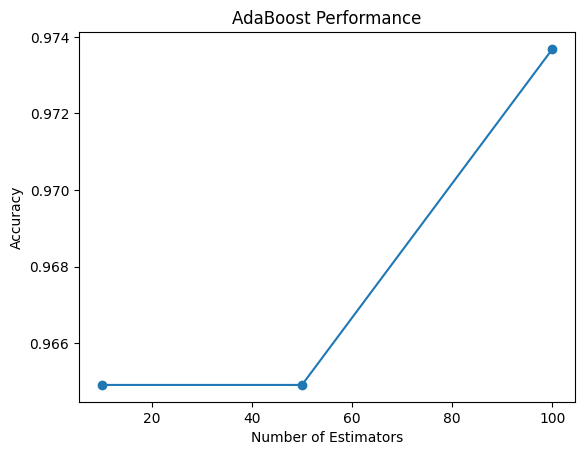

In [2]:
# Import libraries
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt


data = load_breast_cancer()
X = data.data
y = data.target

X = pd.DataFrame(X).fillna(0)

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def evaluate_model(model):
    y_pred = model.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-" * 40)
    
    return accuracy_score(y_test, y_pred)

estimators = [10, 50, 100]
accuracies = []

for n in estimators:
    print(f"\n--- AdaBoost with {n} estimators ---")
    
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),  
        n_estimators=n,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    acc = evaluate_model(model)
    accuracies.append(acc)

plt.plot(estimators, accuracies, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost Performance")
plt.show()

TASK 2

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluation
print("\n--- XGBoost Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature Importance Plot
import matplotlib.pyplot as plt

importances = xgb_model.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()